# Load Data

In [1]:
#load Data
import pandas as pd
import matplotlib.pyplot as pls 
import seaborn as sns
df = pd.read_csv("/kaggle/input/datasets/algozee/rag-based-hallucination-reduction-in-llms/llm_rag_dataset_6k.csv.csv")

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   sample_id                        6000 non-null   int64  
 1   domain                           6000 non-null   object 
 2   question                         6000 non-null   object 
 3   ground_truth_answer              6000 non-null   object 
 4   retrieved_context                6000 non-null   object 
 5   llm_response_without_rag         6000 non-null   object 
 6   llm_response_with_rag            6000 non-null   object 
 7   hallucination_label_without_rag  6000 non-null   int64  
 8   hallucination_label_with_rag     6000 non-null   int64  
 9   hallucination_type               6000 non-null   object 
 10  factual_consistency_score        6000 non-null   float64
 11  context_relevance_score          6000 non-null   float64
 12  source_support_label

# Exploratory Data Analysis
**Hallucination Baseline:** 
- Compare the hallucination rate (Label 1) of "Response without RAG" vs. "Response with RAG."
- This establishes the "lift" provided by retrieval.
- Analyze hallucination types

In [3]:
df[['hallucination_label_without_rag','hallucination_label_with_rag']].value_counts()

hallucination_label_without_rag  hallucination_label_with_rag
1                                0                               3043
0                                0                               2494
1                                1                                415
0                                1                                 48
Name: count, dtype: int64

- 1 without RAG, 0 with RAG --> Saved (Hero)
- 0 withouted RAG, 1 with RAG --> Polluted (Red Flag)
- 1 without RAG, 1 with RAG --> Still Chanllenging (Hard Ceiling)
- 0 without RAG, 0 with RAG --> Easy cases (Baseline Success)

<Axes: xlabel='hallucination_label_without_rag,hallucination_label_with_rag'>

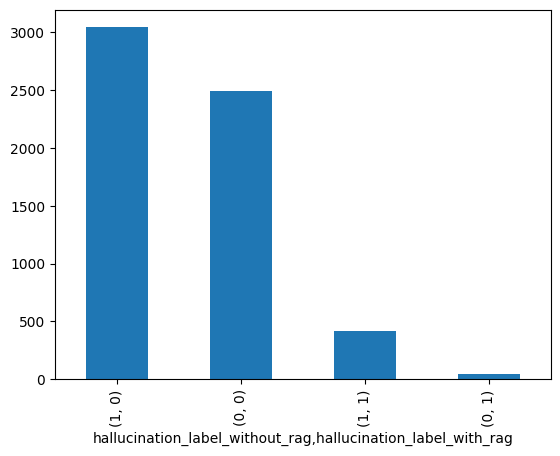

In [4]:
df[['hallucination_label_without_rag','hallucination_label_with_rag']].value_counts().plot(kind="bar")

In [5]:
df["hallucination_type"].value_counts()

hallucination_type
none                 2494
unsupported_claim     995
contradiction         981
factual_error         966
partially_correct     564
Name: count, dtype: int64

<Axes: xlabel='hallucination_type'>

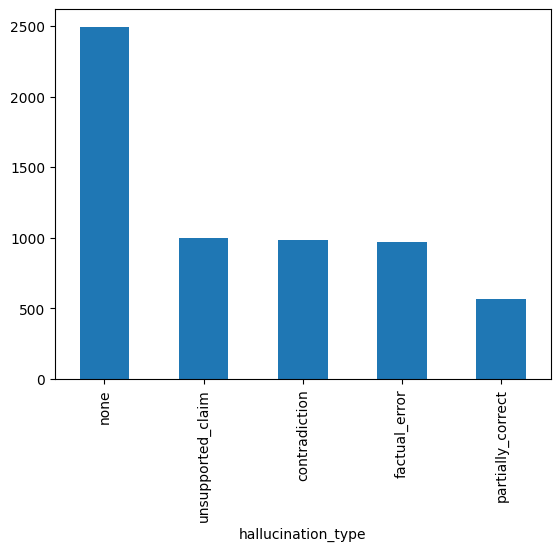

In [6]:
df["hallucination_type"].value_counts().plot(kind="bar")

In [7]:
print("label 1 for hallucination without RAG = ",df["hallucination_label_without_rag"].value_counts().to_dict()[1])
print("label 1 for hallucination with RAG = ",df["hallucination_label_with_rag"].value_counts().to_dict()[1])

label 1 for hallucination without RAG =  3458
label 1 for hallucination with RAG =  463


In [8]:
print("label 1 for hallucination types without RAG = ",df[df["hallucination_label_without_rag"]==1][["hallucination_type"]].value_counts())
print("label 1 for support type without RAG = ",df[df["hallucination_label_without_rag"]==1][["source_support_label"]].value_counts())
print("label 1 for target label without RAG = ",df[df["hallucination_label_without_rag"]==1][["final_target_label"]].value_counts())

label 1 for hallucination types without RAG =  hallucination_type
unsupported_claim     979
contradiction         970
factual_error         954
partially_correct     555
Name: count, dtype: int64
label 1 for support type without RAG =  source_support_label
supported               3043
partially_supported      211
not_supported            204
Name: count, dtype: int64
label 1 for target label without RAG =  final_target_label
0                     3043
1                      415
Name: count, dtype: int64


In [9]:
print("label 1 for hallucination types with RAG = ",df[df["hallucination_label_with_rag"]==1][["hallucination_type"]].value_counts())
print("label 1 for support type with RAG = ",df[df["hallucination_label_with_rag"]==1][["source_support_label"]].value_counts())
print("label 1 for target label with RAG = ",df[df["hallucination_label_with_rag"]==1][["final_target_label"]].value_counts())

label 1 for hallucination types with RAG =  hallucination_type
unsupported_claim     122
contradiction         115
factual_error         113
partially_correct     113
Name: count, dtype: int64
label 1 for support type with RAG =  source_support_label
partially_supported     236
not_supported           227
Name: count, dtype: int64
label 1 for target label with RAG =  final_target_label
1                     463
Name: count, dtype: int64


In [10]:
print("polluted hallucination type",df[(df["hallucination_label_with_rag"]==1) & (df["hallucination_label_without_rag"]==0)][["hallucination_type"]].value_counts())
print("*************************************")
print("polluted support label",df[(df["hallucination_label_with_rag"]==1) & (df["hallucination_label_without_rag"]==0)][["source_support_label"]].value_counts())
print("*************************************")
print("polluted target label",df[(df["hallucination_label_with_rag"]==1) & (df["hallucination_label_without_rag"]==0)][["final_target_label"]].value_counts())

polluted hallucination type hallucination_type
unsupported_claim     16
factual_error         12
contradiction         11
partially_correct      9
Name: count, dtype: int64
*************************************
polluted support label source_support_label
partially_supported     25
not_supported           23
Name: count, dtype: int64
*************************************
polluted target label final_target_label
1                     48
Name: count, dtype: int64


**Metric Correlation:**
- How Factual Consistency and Context Relevance correlate with the Hallucination Label.

In [11]:
print("Correlation of label 1 hallucination with RAG")
df[df["hallucination_label_with_rag"]==1][["factual_consistency_score","context_relevance_score"]].corr()

Correlation of label 1 hallucination with RAG


,factual_consistency_score,context_relevance_score
factual_consistency_score,1.000000,0.017343
context_relevance_score,0.017343,1.000000


**Observations:**
- With RAG
- hallucination = 1
- correlation a negligible or near-zero linear relationship

In [12]:
print("Correlation of label 0 hallucination with RAG")
df[df["hallucination_label_with_rag"]==0][["factual_consistency_score","context_relevance_score"]].corr()

Correlation of label 0 hallucination with RAG


,factual_consistency_score,context_relevance_score
factual_consistency_score,1.000000,0.015332
context_relevance_score,0.015332,1.000000


**Observations:**
- With RAG
- hallucination = 0
- correlation a negligible or near-zero linear relationship

In [13]:
print("Correlation of label 1 hallucination without RAG")
df[df["hallucination_label_without_rag"]==1][["factual_consistency_score","context_relevance_score"]].corr()

Correlation of label 1 hallucination without RAG


,factual_consistency_score,context_relevance_score
factual_consistency_score,1.000000,-0.139532
context_relevance_score,-0.139532,1.000000


**Observations:**
- Without RAG
- hallucination = 1
- correlation a very weak, negative (inverse) linear relationship 

In [14]:
print("Correlation of label 0 hallucination without RAG")
df[df["hallucination_label_without_rag"]==0][["factual_consistency_score","context_relevance_score"]].corr()

Correlation of label 0 hallucination without RAG


,factual_consistency_score,context_relevance_score
factual_consistency_score,1.000000,0.276064
context_relevance_score,0.276064,1.000000


**Observations:**
- Without RAG
- hallucination = 0
- correlation a very weak, positive linear relationship 

<Axes: xlabel='factual_consistency_score', ylabel='context_relevance_score'>

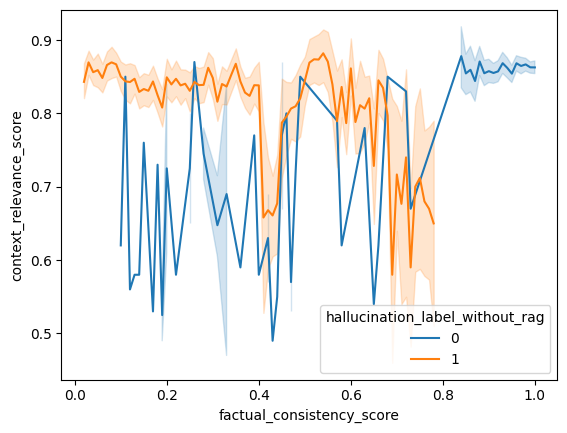

In [15]:
sns.lineplot(x="factual_consistency_score",y="context_relevance_score",hue="hallucination_label_without_rag",data=df)

<Axes: xlabel='factual_consistency_score', ylabel='context_relevance_score'>

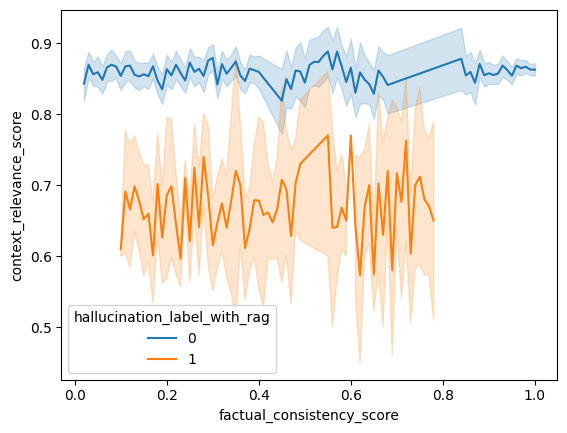

In [16]:
sns.lineplot(x="factual_consistency_score",y="context_relevance_score",hue="hallucination_label_with_rag",data=df)

In [17]:
print("**********************************Factual Consistency*****************************************")
print("Mean of factual hallucination=1 without RAG",df[df["hallucination_label_without_rag"]==1][["factual_consistency_score"]].mean())
print("Mean of factual hallucination=1 with RAG",df[df["hallucination_label_with_rag"]==1][["factual_consistency_score"]].mean())
print("***********************************************************************************************")
print("Mean of factual hallucination=0 without RAG",df[df["hallucination_label_without_rag"]==0][["factual_consistency_score"]].mean())
print("Mean of factual hallucination=0 with RAG",df[df["hallucination_label_with_rag"]==0][["factual_consistency_score"]].mean())
print("************************************Context Relevance*****************************************")
print("Mean of contextual hallucination=1 without RAG",df[df["hallucination_label_without_rag"]==1][["context_relevance_score"]].mean())
print("Mean of contextual hallucination=1 with RAG",df[df["hallucination_label_with_rag"]==1][["context_relevance_score"]].mean())
print("***********************************************************************************************")
print("Mean of contextual hallucination=0 without RAG",df[df["hallucination_label_without_rag"]==0][["context_relevance_score"]].mean())
print("Mean of contextual hallucination=0 with RAG",df[df["hallucination_label_with_rag"]==0][["context_relevance_score"]].mean())

**********************************Factual Consistency*****************************************
Mean of factual hallucination=1 without RAG factual_consistency_score    0.277423
dtype: float64
Mean of factual hallucination=1 with RAG factual_consistency_score    0.384665
dtype: float64
***********************************************************************************************
Mean of factual hallucination=0 without RAG factual_consistency_score    0.944095
dtype: float64
Mean of factual hallucination=0 with RAG factual_consistency_score    0.57452
dtype: float64
************************************Context Relevance*****************************************
Mean of contextual hallucination=1 without RAG context_relevance_score    0.836171
dtype: float64
Mean of contextual hallucination=1 with RAG context_relevance_score    0.665486
dtype: float64
***********************************************************************************************
Mean of contextual hallucination=0 without R

Hallucination Types without RAG


<Axes: xlabel='hallucination_type', ylabel='count'>

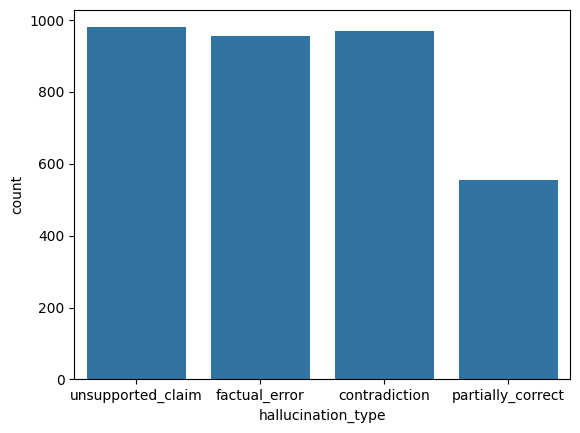

In [18]:
print("Hallucination Types without RAG")
sns.countplot(x="hallucination_type",data=df[df["hallucination_label_without_rag"]==1])

Hallucination Types with RAG


<Axes: xlabel='hallucination_type', ylabel='count'>

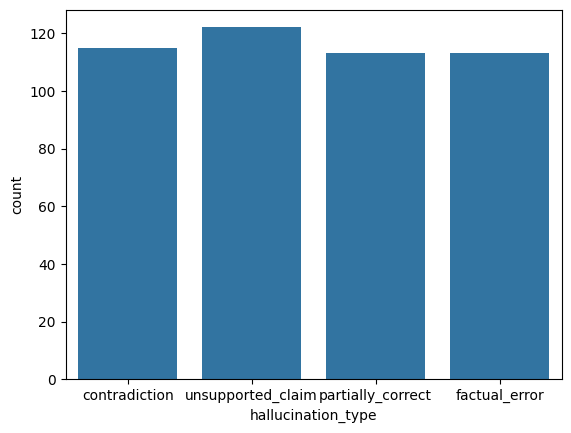

In [19]:
print("Hallucination Types with RAG")
sns.countplot(x="hallucination_type",data=df[df["hallucination_label_with_rag"]==1])

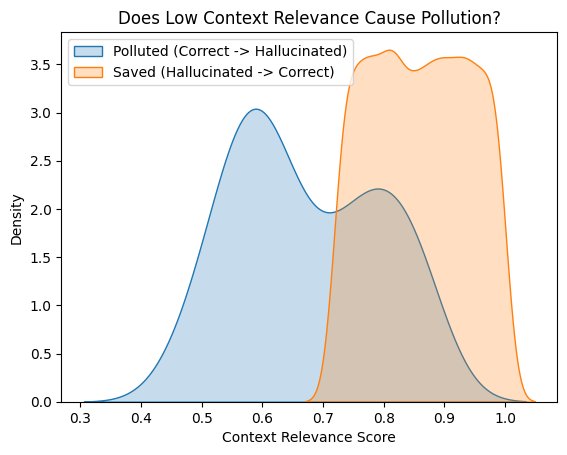

In [20]:
# Create the 4 groups for comparison
polluted = df[(df['hallucination_label_without_rag'] == 0) & (df['hallucination_label_with_rag'] == 1)]
saved = df[(df['hallucination_label_without_rag'] == 1) & (df['hallucination_label_with_rag'] == 0)]
# Plot the distribution of relevance scores
import matplotlib.pyplot as plt
plt.figure()
sns.kdeplot(polluted['context_relevance_score'], label='Polluted (Correct -> Hallucinated)', fill=True)
sns.kdeplot(saved['context_relevance_score'], label='Saved (Hallucinated -> Correct)', fill=True)
plt.title('Does Low Context Relevance Cause Pollution?')
plt.xlabel('Context Relevance Score')
plt.legend()
plt.savefig('relevance_analysis.png')

# Modelling

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# 1. Prepare your Features and Target
# if these two scores predict the RAG outcome
X = df[['factual_consistency_score', 'context_relevance_score']]
y = df['hallucination_label_with_rag']

# 2. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- MODEL A: Logistic Regression (The Linear Baseline) ---
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("--- Logistic Regression Performance ---")
print(classification_report(y_test, lr_preds))
print(f"Coefficients (Weights): {lr_model.coef_}") 
# These coefficients tell you which score matters more!

--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1103
           1       1.00      0.40      0.57        97

    accuracy                           0.95      1200
   macro avg       0.98      0.70      0.77      1200
weighted avg       0.95      0.95      0.94      1200

Coefficients (Weights): [[ -1.41252233 -13.62835545]]



--- Decision Tree Performance ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1103
           1       1.00      0.63      0.77        97

    accuracy                           0.97      1200
   macro avg       0.98      0.81      0.88      1200
weighted avg       0.97      0.97      0.97      1200



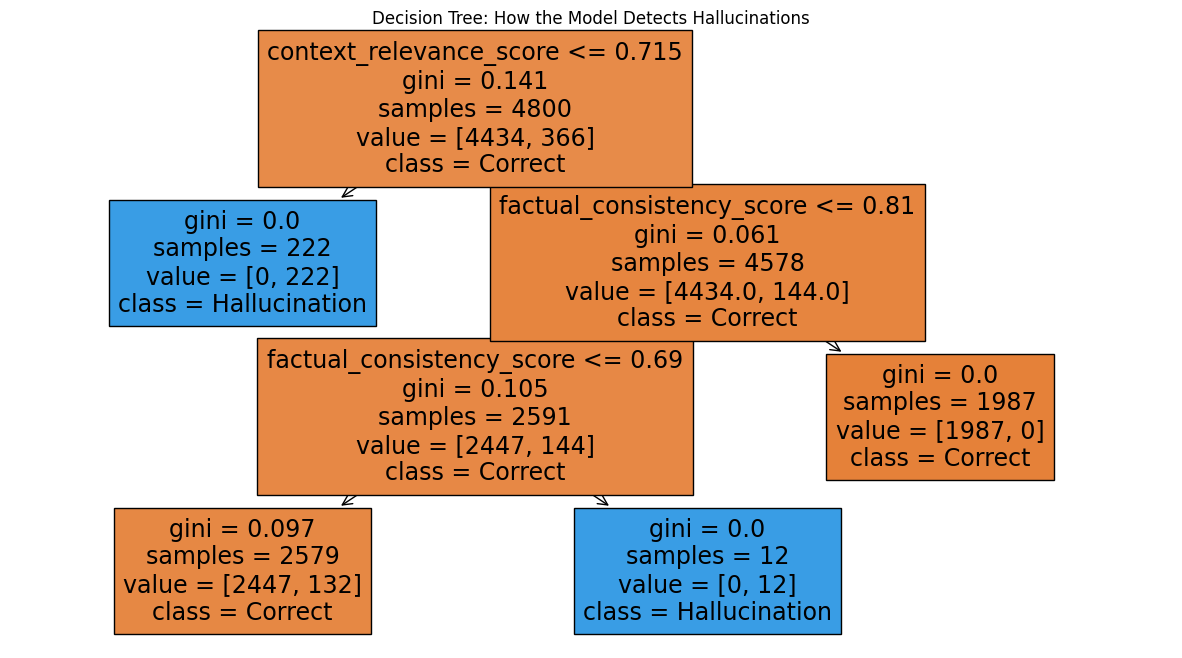

In [22]:
# --- MODEL B: Decision Tree (The Rule-Based Logic) ---
dt_model = DecisionTreeClassifier(max_depth=3) # Depth 3 keeps it readable
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

print("\n--- Decision Tree Performance ---")
print(classification_report(y_test, dt_preds))

# Visualize the Decision Tree to see the 'Rules' for Hallucination
plt.figure(figsize=(15,8))
plot_tree(dt_model, feature_names=X.columns, class_names=['Correct', 'Hallucination'], filled=True)
plt.title("Decision Tree: How the Model Detects Hallucinations")
plt.show()

# Key TakeAways
- RAG is acting as a double-edged sword. While it offers a slight safety net for errors, it is significantly "polluting" correct answers.
- RAG decreases factual erros and contradiction signifinatly
- RAG still lake context efficiency